# PROGETTO di Ghiani Caterina
### *Corso di Introduzione alla data science e al pensiero computazionale - anno accademico 2025/2026*
### **Caterina Ghiani:** matricola 1181102, caterina.ghiani@studio.unibo.it

# 0. Preparazione dell'ambiente
### prima di iniziare la nostra analisi, bisogna importare le librerie necessarie

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import svm, tree
from sklearn.metrics import *

# 1. Descrizione e comprensione del dataset

Questo dataset contiene informazioni relative ai clienti di carte di credito, inclusi dati demografici, limiti di credito, cronologia delle fatturazioni e storico dei pagamenti. Ogni record rappresenta un cliente e fornisce diverse variabili utili per valutare l'affidabilità finanziaria.

L'obiettivo della classificazione è prevedere se un cliente andrà in default (inadempienza) sul pagamento del mese successivo. La variabile target indica se il cliente non ha rispettato gli obblighi di pagamento nel mese seguente. Questo problema è particolarmente rilevante nel settore finanziario, dove i modelli predittivi aiutano gli istituti a identificare i clienti ad alto rischio e a supportare le decisioni di gestione del credito.

La ricerca utilizza una variabile binaria come risposta: default payment (Sì = 1, No = 0).

In [2]:
credit = pd.read_csv("Credit_Card_Default.csv", header=1) #questo per eliminare la riga con scritto X1, X2, etc.

In [3]:
credit

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


La nostra variabile target è "default payment next month" è la nostra Y

### Struttura generale e qualità dei dati

In [4]:
if 'ID' in credit.columns:
    credit = credit.drop(columns=['ID']) # eliminiamo questa "feature" perchè non aggiunge niente alla nostra analisi, è solo un identificativo


In [5]:
credit_num_righe = credit.shape[0]
credit_num_colonne = credit.shape[1]
print("Numero righe", credit_num_righe)
print("Numero colonne", credit_num_colonne)

print()

Numero righe 30000
Numero colonne 24



In [6]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

Rinominiamo PAY_0 in PAY_1 per coerenza con il nome delle altre variabili, supponendo sia stata una svista da parte di chi ha inviato il dataset

In [7]:
credit = credit.rename(columns={'PAY_0': 'PAY_1'})

Andiamo alla ricerca di valori nulli e osserviamo che non ce ne sono

In [8]:
print(credit.isnull().sum())

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_1                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64


Cerchiamo di capire che valori possono assumere le nostre variabili categoriali

In [9]:
list_cat = ["SEX", "EDUCATION", "MARRIAGE", "PAY_1", "PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

In [10]:
for stringa in list_cat:
  unici = credit[stringa].unique()
  print(stringa)
  print(unici)

SEX
[2 1]
EDUCATION
[2 1 3 5 4 6 0]
MARRIAGE
[1 2 3 0]
PAY_1
[ 2 -1  0 -2  1  3  4  8  7  5  6]
PAY_1
[ 2 -1  0 -2  1  3  4  8  7  5  6]
PAY_2
[ 2  0 -1 -2  3  5  7  4  1  6  8]
PAY_3
[-1  0  2 -2  3  4  6  7  1  5  8]
PAY_4
[-1  0 -2  2  3  4  5  7  6  1  8]
PAY_5
[-2  0 -1  2  3  5  4  7  8  6]
PAY_6
[-2  2  0 -1  3  6  4  7  8  5]


Osserviamo che le variabili PAY_X, le quali esprimono di quanti mesi è in ritardo il titolare della carta nei pagamenti, possono assumere anche valori diversi da quelli indicati nella legenda. Valori quali: -2 e 0. Assumendo che questi valori significhino che il titolare o non ha debiti da pagare o ha già pagato il minimo per non essere in morosità ricodifichiamo le variabili. Nel momento in cui assumono valori quali -2, -1 e 0 consideriamo il cliente solvente e quindi le ricodifichiamo con 0.

In [11]:
cols_pay = ["PAY_1", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
mapping = {-2:0,
           -1:0,
            0:0
}

for col in cols_pay:
  credit[col] = credit[col].replace(mapping) # applica la nuova mappatura

for col in cols_pay:
    print(f"{col}: {credit[col].unique()}") #verifica dei valori unici

PAY_1: [2 0 1 3 4 8 7 5 6]
PAY_2: [2 0 3 5 7 4 1 6 8]
PAY_3: [0 2 3 4 6 7 1 5 8]
PAY_4: [0 2 3 4 5 7 6 1 8]
PAY_5: [0 2 3 5 4 7 8 6]
PAY_6: [0 2 3 6 4 7 8 5]


La medesima osservazione fatta per PAY_X si può fare anche per EDUCATION. Secondo la legenda infatti, la variabile potrebbe assumere solo 4 valori, mentre invece assume anche il valore 0, 5 e 6. Dopo aver capito quante osservazioni assumono i valori non codificati, procediamo con la ricodifica di questi valori "anomali" all'interno della categoria 4 - Other, siccome non possiamo escludere osservazioni dalla nostra analisi e non possiamo attribuire un significato univoco a questi valori.

In [12]:
print(credit['EDUCATION'].value_counts())

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


In [13]:
mapping = { 0:4,
            5:4,
            6:4
}

credit['EDUCATION'] = credit['EDUCATION'].replace(mapping) # applica la nuova mappatura

print(credit['EDUCATION'].unique())

[2 1 3 4]


La medesima situazione la ritroviamo anche in MARRIAGE, dove la variabile ha assunto 54 volte anche il valore 0. Anche in questa situazione ricodifichiamo i valori che assumono 0, nella categoria 3 che corrisponde a "Other"

In [14]:
print(credit['MARRIAGE'].value_counts())

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [15]:
credit['MARRIAGE'] = credit['MARRIAGE'].replace({0: 3})

print(credit['MARRIAGE'].unique())

[1 2 3]


Per comodità per l'interpretazione dei modelli, ricodificiamo anche la variabile SEX in modo che maschio = 0 e femmina = 1

In [16]:
mapping = { 1:0, # maschio
            2:1  # femmina
}

credit['SEX'] = credit['SEX'].replace(mapping) # applica la nuova mappatura

print(credit['SEX'].unique())

[1 0]


Calcoliamo la frequenza delle variabili categoriali

### Statistiche descrittive fondamentali

In [17]:
credit["AGE"].describe()

,AGE
count,30000.000000
mean,35.485500
std,9.217904
min,21.000000
25%,28.000000
50%,34.000000
75%,41.000000
max,79.000000


In [18]:
credit["LIMIT_BAL"].describe()

,LIMIT_BAL
count,30000.000000
mean,167484.322667
std,129747.661567
min,10000.000000
25%,50000.000000
50%,140000.000000
75%,240000.000000
max,1000000.000000


In [19]:
credit["BILL_AMT1"].describe()

,BILL_AMT1
count,30000.000000
mean,51223.330900
std,73635.860576
min,-165580.000000
25%,3558.750000
50%,22381.500000
75%,67091.000000
max,964511.000000


In [20]:
list_cat = ["SEX", "EDUCATION", "MARRIAGE", "default payment next month"]
for stringa in list_cat:
  print("---")
  freq_credit = credit[stringa].value_counts(normalize=True)*100
  print("Credit:", freq_credit)

---
Credit: SEX
1    60.373333
0    39.626667
Name: proportion, dtype: float64
---
Credit: EDUCATION
2    46.766667
1    35.283333
3    16.390000
4     1.560000
Name: proportion, dtype: float64
---
Credit: MARRIAGE
2    53.213333
1    45.530000
3     1.256667
Name: proportion, dtype: float64
---
Credit: default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64


### Analisi esplorativa

***Ipotesi di ricerca:***


1.   Il dataset è bilanciato rispetto alla variabile target?
2.   L'età differisce in modo significativo tra clienti in default e clienti solvibili?
3.   Un livello d'istruzione più elevato si associa ad una maggiore probabilità di essere solvente?
4.   Esiste una differenza in base al genere che rende i soggetti più o meno probabili di essere in default?
5.   Un soggetto sposato è più probabile che vada in default o che sia solvente?
6.   Un limite di credito concesso più basso segnala un soggetto più a rischio di default?
7.   Lo stato di ritardo nei pagamenti precedenti ci indica chi ha più probabilità di andare in default o no?
8.   Un elevato rapporto tra spesa mensile e prestito concesso, aumenta la probabilità di default? Cioè chi usa sempre al massimo il credito concesso, alla fine va in default più spesso di chi invece non raggiunge il tetto di spesa?
9.   Gli importi dei pagamenti mensili, sono simili?



**1. Distribuzione della variabile target Y**

In [21]:
counts = credit['default payment next month'].value_counts()
perc = credit['default payment next month'].value_counts(normalize=True) * 100

target_dist = pd.DataFrame({
    'Conteggio (N)': counts,
    'Percentuale (%)': perc.round(2),
})

target_dist.index = ['Solvibile (0)', 'Default (1)']

print("--- DISTRIBUZIONE DELLA VARIABILE TARGET ---")
print(target_dist)

--- DISTRIBUZIONE DELLA VARIABILE TARGET ---
               Conteggio (N)  Percentuale (%)
Solvibile (0)          23364            77.88
Default (1)             6636            22.12


Circa il ***22%*** (6636) dei soggetti va in default, mentre il ***78%*** è in pari con i pagamenti

**2. Distribuzione dell'età per conoscere l'età media dei clienti e se vi sono fasce d'età più a rischio default**

In [22]:
credit_age = credit.AGE.max()
print ("Il valore massimo di età in credit è:", credit_age)

print()

credit_age = credit.AGE.min()
print ("Il valore minimo di età in credit è:", credit_age)

print()

credit_age = credit.AGE.var()
print ("La varianza di età in credit è: ", credit_age)


Il valore massimo di età in credit è: 79

Il valore minimo di età in credit è: 21

La varianza di età in credit è:  84.96975540851355


Da questo sappiamo che l'età massima dei clienti è di 79 anni e minima di 21. Inoltre la nostra varianza è alta indicando che ci troviamo di fronte ad un dataset vario.

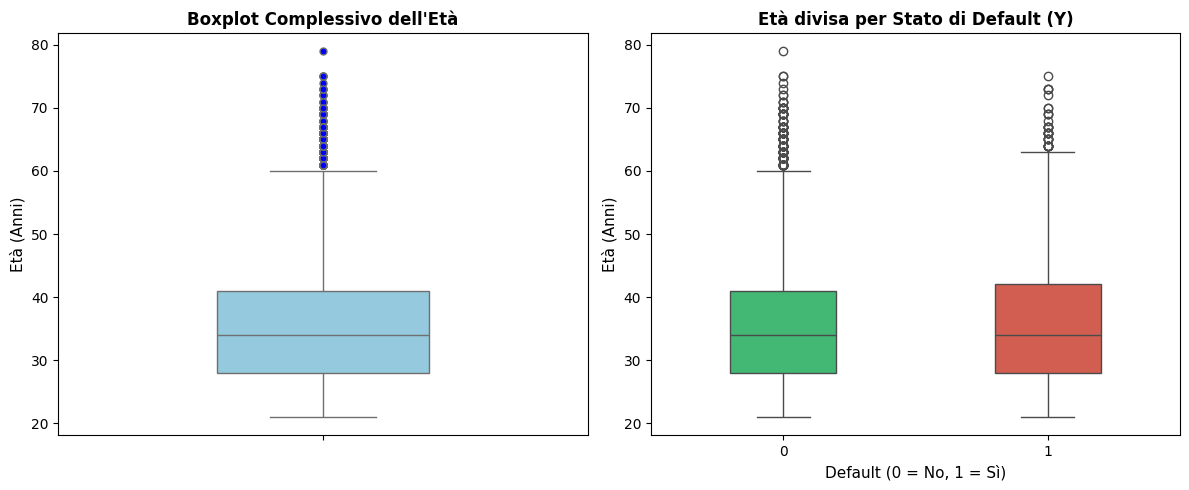

In [23]:
# grafici uno accanto all'altro
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot Complessivo (Identificazione Outlier)
sns.boxplot(
    data=credit,
    y='AGE',
    color='skyblue',
    width=0.4,
    flierprops={'marker': 'o', 'markerfacecolor': 'blue', 'markersize': 5},
    ax=axes[0]
)
axes[0].set_title('Boxplot Complessivo dell\'Età', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Età (Anni)', fontsize=11)

# Boxplot Bivariato diviso per Target Y
sns.boxplot(
    data=credit,
    x='default payment next month',
    y='AGE',
    hue='default payment next month',
    palette=['#2ecc71', '#e74c3c'],
    legend=False,
    width=0.4,
    ax=axes[1]
)
axes[1].set_title('Età divisa per Stato di Default (Y)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Default (0 = No, 1 = Sì)', fontsize=11)
axes[1].set_ylabel('Età (Anni)', fontsize=11)

plt.tight_layout()

# Salvataggio per la relazione in LaTeX
plt.savefig('boxplot_age_target.png', dpi=300, bbox_inches='tight')
plt.show()

Dall'analisi del boxplot complessivo per la variabile ***AGE***, si rileva una mediana pari a circa 34 anni, con un range interquartile compreso tra 28 e 41 anni. La presenza di valori anomali statistici sopra i 60 anni rispecchia la naturale distribuzione demografica dei titolari di carta di credito e non costituisce un errore nei dati.

Il confronto bivariato rispetto alla variabile target Y evidenzia una quasi totale sovrapposizione tra la distribuzione dei clienti solvibili Y=0 e quelli in default Y=1. Ciò suggerisce che l'età, non è un fattore che determina la capacità di ripagare i propri debiti

**3. Distribuzione del livello d'istruzione per vedere se tassi di default più elevati si concentrano in specifici livelli di istruzione**

=== DISTRIBUZIONE DELL'ISTRUZIONE NEL CAMPIONE (%) ===
                                    Conteggio (N)  Percentuale sul Totale (%)
Università (2)                              14030                       46.77
Specialistica/master/dottorato (1)          10585                       35.28
Scuola superiore (3)                         4917                       16.39
Others (4)                                    468                        1.56


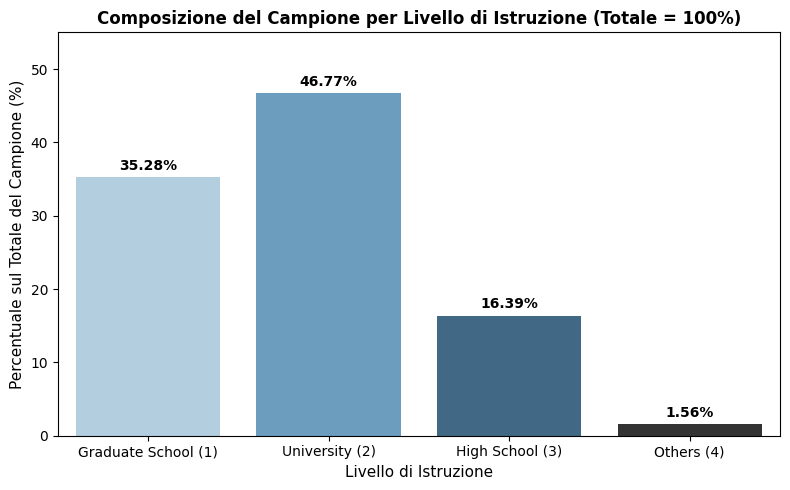

In [25]:
# 1. Distribuzione percentuale dell'Istruzione sul TOTALE del campione (Somma = 100%)
edu_dist = credit['EDUCATION'].value_counts(normalize=True) * 100
edu_counts = credit['EDUCATION'].value_counts()

df_edu_sample = pd.DataFrame(
    {'Conteggio (N)': edu_counts, 'Percentuale sul Totale (%)': edu_dist.round(2)}
)

df_edu_sample.index = [
    'Università (2)',
    'Specialistica/master/dottorato (1)',
    'Scuola superiore (3)',
    'Others (4)',
]

print("=== DISTRIBUZIONE DELL'ISTRUZIONE NEL CAMPIONE (%) ===")
print(df_edu_sample)

# 2. Grafico a barre della composizione del campione
plt.figure(figsize=(8, 5))

# Calcoliamo le percentuali per categoria ordinate da 1 a 4
edu_pct_ordered = (
    credit['EDUCATION'].value_counts(normalize=True).sort_index() * 100
)

ax = sns.barplot(
    x=edu_pct_ordered.index,
    y=edu_pct_ordered.values,
    hue=edu_pct_ordered.index,
    palette='Blues_d',
    legend=False,
)

plt.title(
    'Composizione del Campione per Livello di Istruzione (Totale = 100%)',
    fontsize=12,
    fontweight='bold',
)
plt.xlabel('Livello di Istruzione', fontsize=11)
plt.ylabel('Percentuale sul Totale del Campione (%)', fontsize=11)
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        'Graduate School (1)',
        'University (2)',
        'High School (3)',
        'Others (4)',
    ],
)

# Etichette sopra ogni barra con percentuale sul totale
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2f}%',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
    )

plt.ylim(0, 55)
plt.tight_layout()
plt.savefig('education_sample_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

**4. Distribuzione del Genere**

Esiste una differenza tra maschi e femmine riguardo la loro probabilità di andare in default?



--- CONFRONTO SOLVIBILI/INSOLVENTI PER TITOLO DI STUDIO ---
                                    Solvibili (N)  Insolventi (N)  Totale (N)  \
(1) Specialistica/master/dottorato           8549            2036       10585   
(2) Università                              10700            3330       14030   
(3) Scuola superiore                         3680            1237        4917   
(4) Altro                                     435              33         468   
Totale                                      23364            6636       30000   

                                    Solvibili (%)  Insolventi (%)  
(1) Specialistica/master/dottorato          80.77           19.23  
(2) Università                              76.27           23.73  
(3) Scuola superiore                        74.84           25.16  
(4) Altro                                   92.95            7.05  
Totale                                      77.88           22.12  


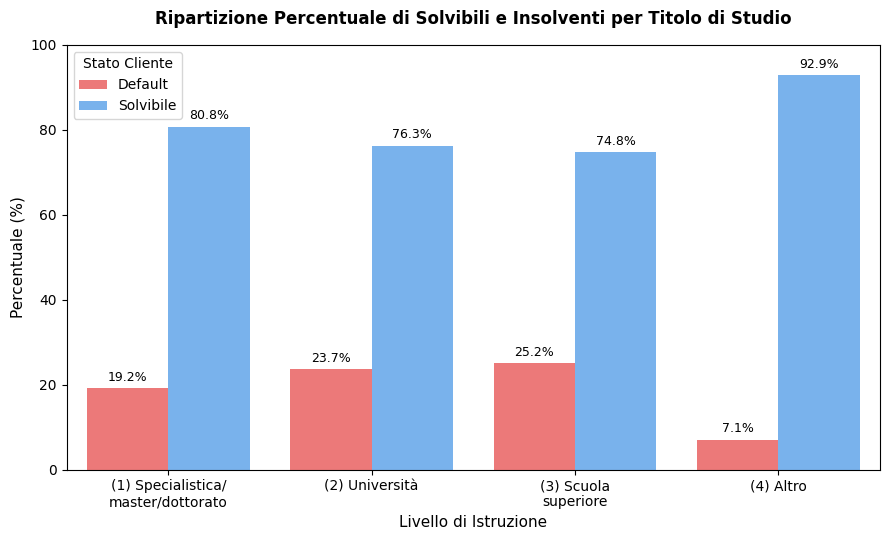

In [43]:
# Mappatura delle categorie in italiano
edu_labels = {
    1: '(1) Specialistica/master/dottorato',
    2: '(2) Università',
    3: '(3) Scuola superiore',
    4: '(4) Altro',
}

# 1. TABELLA: Conteggi e Percentuali per Riga
# Conteggi (N)
ct_counts = pd.crosstab(
    credit['EDUCATION'],
    credit['default payment next month'],
    margins=True,
    margins_name='Totale',
)

# Percentuali per riga (%)
ct_pct = (
    pd.crosstab(
        credit['EDUCATION'],
        credit['default payment next month'],
        normalize='index',
    )
    * 100
)

# Costruzione DataFrame unificato (escludiamo la riga Totale dalle percentuali per non alterare la mappa)
# Create the DataFrame with count columns first
df_table = pd.DataFrame({
    'Solvibili (N)': ct_counts[0],
    'Insolventi (N)': ct_counts[1],
    'Totale (N)': ct_counts['Totale']
})

# Add percentage columns, pandas will align indices and add NaN for 'Totale' row
df_table['Solvibili (%)'] = ct_pct[0].round(2)
df_table['Insolventi (%)'] = ct_pct[1].round(2)

# Sostituiamo i NaN della riga 'Totale' con il tasso globale del dataset
df_table.loc['Totale', 'Solvibili (%)'] = round(
    (ct_counts.loc['Totale', 0] / ct_counts.loc['Totale', 'Totale']) * 100, 2
)
df_table.loc['Totale', 'Insolventi (%)'] = round(
    (ct_counts.loc['Totale', 1] / ct_counts.loc['Totale', 'Totale']) * 100, 2
)

# Rinominiamo gli indici (ora 'Totale' manterrà le sue percentuali corrette)
df_table.index = [
    edu_labels.get(i, 'Totale') for i in df_table.index[:-1]
] + ['Totale']

print("--- CONFRONTO SOLVIBILI/INSOLVENTI PER TITOLO DI STUDIO ---")
print(df_table)

# 2. GRAFICO A BARRE AFFIANCATE (Oppure Sovrapposte)
# Prepariamo i dati per il grafico percentuale
credit_plot = credit.copy()
credit_plot['EDUCATION_LABEL'] = credit_plot['EDUCATION'].map(edu_labels)
credit_plot['TARGET_LABEL'] = credit_plot[
    'default payment next month'
].map({0: 'Solvibile', 1: 'Default'})

# Calcoliamo le percentuali normalizzate per categoria per il grafico in modo più robusto
df_chart = (
    credit_plot.groupby(['EDUCATION_LABEL', 'TARGET_LABEL'])
    .size()
    .reset_index(name='Count')
)
df_chart['Percentuale'] = df_chart.groupby('EDUCATION_LABEL')['Count'].transform(lambda x: 100 * x / x.sum())
df_chart = df_chart.drop(columns=['Count'])

plt.figure(figsize=(9, 5.5))

ax = sns.barplot(
    data=df_chart,
    x='EDUCATION_LABEL',
    y='Percentuale',
    hue='TARGET_LABEL',
    palette=['#ff6666', '#66b2ff'],
    order=[
        '(1) Specialistica/master/dottorato',
        '(2) Università',
        '(3) Scuola superiore',
        '(4) Altro',
    ],
)

plt.title(
    'Ripartizione Percentuale di Solvibili e Insolventi per Titolo di Studio',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Livello di Istruzione', fontsize=11)
plt.ylabel('Percentuale (%)', fontsize=11)
plt.legend(title='Stato Cliente', frameon=True)

# Etichette asse X formattate
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        '(1) Specialistica/\nmaster/dottorato',
        '(2) Università',
        '(3) Scuola\nsuperiore',
        '(4) Altro',
    ],
    fontsize=10,
)

# Etichette percentuali sopra ciascuna barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=9,
        )

plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('education_stacked_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

--- DISTRIBUZIONE DEFAULT PER GENERE (VALORI ASSOLUTI E %) ---
             Solvibili (N)  Solvibili (%)  Default (N)  Default (%)  \
Maschio (0)           9015          75.83         2873        24.17   
Femmina (1)          14349          79.22         3763        20.78   

             Totale Clienti  
Maschio (0)           11888  
Femmina (1)           18112  


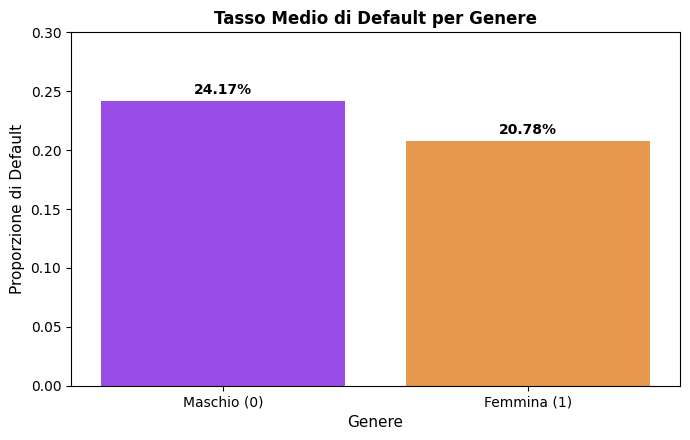

In [115]:
# 1. Tabella dei valori assoluti + percentuali
ct_counts = pd.crosstab(credit['SEX'], credit['default payment next month'])

ct_pct = (
    pd.crosstab(
        credit['SEX'], credit['default payment next month'], normalize='index'
    )
    * 100
)

ct_combined = pd.DataFrame({
    'Solvibili (N)': ct_counts[0],
    'Solvibili (%)': ct_pct[0].round(2),
    'Default (N)': ct_counts[1],
    'Default (%)': ct_pct[1].round(2),
    'Totale Clienti': ct_counts.sum(axis=1),
})

# Rinominiamo gli indici di riga
ct_combined.index = ['Maschio (0)', 'Femmina (1)']

print("--- DISTRIBUZIONE DEFAULT PER GENERE (VALORI ASSOLUTI E %) ---")
print(ct_combined)

# 2. Grafico delle percentuali di Default per Genere
plt.figure(figsize=(7, 4.5))

ax = sns.barplot(
    data=credit,
    x='SEX',
    y='default payment next month',
    hue='SEX',
    palette=['#9933ff', '#ff9933'],
    errorbar=None,
    legend=False,
)

plt.title(
    'Tasso Medio di Default per Genere', fontsize=12, fontweight='bold'
)
plt.xlabel('Genere', fontsize=11)
plt.ylabel('Proporzione di Default', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Maschio (0)', 'Femmina (1)'])

# percentuale sopra ogni barra
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.2%}',
        (p.get_x() + p.get_width() / 2.0, height),
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold',
    )

plt.ylim(0, 0.3)
plt.tight_layout()
plt.savefig('default_by_sex.png', dpi=300, bbox_inches='tight')
plt.show()

Le donne sono più affidabili degli uomini nel pagamento dei propri debiti ma non in maniera sostanziale, cioè tanto da farci considerare il genere una discriminante.

**5. Un soggetto sposato è più probabile che sia solvibile?**

--- CONFRONTO SOLVIBILI/INSOLVENTI PER STATO CIVILE ---
             Solvibili (N)  Insolventi (N)  Totale (N)  Solvibili (%)  \
1 sposato/a          10453            3206       13659          76.53   
2 single             12623            3341       15964          79.07   
3 altro                288              89         377          76.39   
Totale               23364            6636       30000          77.88   

             Insolventi (%)  
1 sposato/a           23.47  
2 single              20.93  
3 altro               23.61  
Totale                22.12  


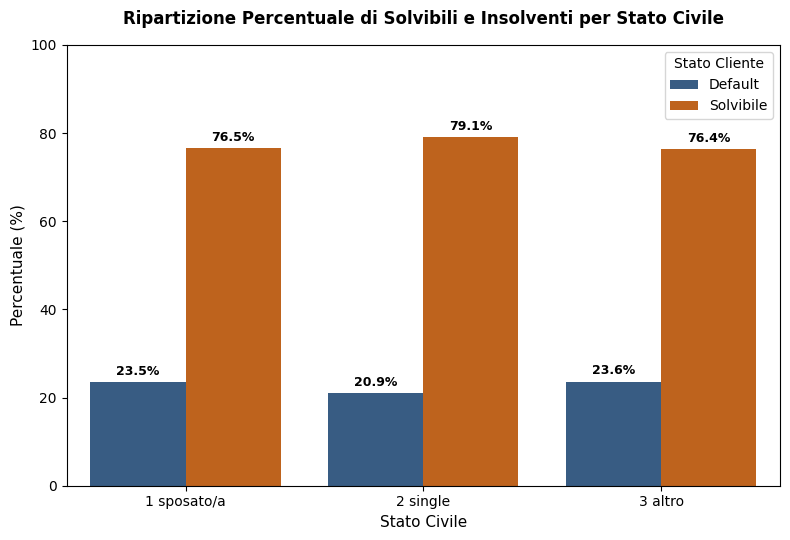

In [44]:
# Mappatura in italiano della variabile MARRIAGE
marriage_labels = {1: "1 sposato/a", 2: "2 single", 3: "3 altro"}

# 1. TABELLA: Conteggi e Percentuali per Riga
ct_counts = pd.crosstab(
    credit["MARRIAGE"],
    credit["default payment next month"],
    margins=True,
    margins_name="Totale",
)
ct_pct = (
    pd.crosstab(
        credit["MARRIAGE"],
        credit["default payment next month"],
        normalize="index",
    )
    * 100
)

df_marriage_table = pd.DataFrame({
    "Solvibili (N)": ct_counts[0],
    "Insolventi (N)": ct_counts[1],
    "Totale (N)": ct_counts["Totale"],
})

df_marriage_table["Solvibili (%)"] = ct_pct[0].round(2)
df_marriage_table["Insolventi (%)"] = ct_pct[1].round(2)

# Correzione riga Totale con tassi globali
df_marriage_table.loc["Totale", "Solvibili (%)"] = round(
    (
        ct_counts.loc["Totale", 0]
        / ct_counts.loc["Totale", "Totale"]
    )
    * 100,
    2,
)
df_marriage_table.loc["Totale", "Insolventi (%)"] = round(
    (
        ct_counts.loc["Totale", 1]
        / ct_counts.loc["Totale", "Totale"]
    )
    * 100,
    2,
)

# Rinominiamo gli indici
df_marriage_table.index = [
    marriage_labels.get(i, "Totale")
    for i in df_marriage_table.index[:-1]
] + ["Totale"]

print("--- CONFRONTO SOLVIBILI/INSOLVENTI PER STATO CIVILE ---")
print(df_marriage_table)

# 2. GRAFICO A BARRE AFFIANCATE
credit_plot = credit.copy()
credit_plot["MARRIAGE_LABEL"] = credit_plot["MARRIAGE"].map(
    marriage_labels
)
credit_plot["TARGET_LABEL"] = credit_plot[
    "default payment next month"
].map({0: "Solvibile", 1: "Default"})

df_marriage_chart = (
    credit_plot.groupby(["MARRIAGE_LABEL", "TARGET_LABEL"])
    .size()
    .reset_index(name="Count")
)
df_marriage_chart["Percentuale"] = df_marriage_chart.groupby(
    "MARRIAGE_LABEL"
)["Count"].transform(lambda x: 100 * x / x.sum())

plt.figure(figsize=(8, 5.5))

ax = sns.barplot(
    data=df_marriage_chart,
    x="MARRIAGE_LABEL",
    y="Percentuale",
    hue="TARGET_LABEL",
    palette=["#2b5c8f", "#d95f02"],
    order=["1 sposato/a", "2 single", "3 altro"],
)

plt.title(
    "Ripartizione Percentuale di Solvibili e Insolventi per Stato Civile",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Stato Civile", fontsize=11)
plt.ylabel("Percentuale (%)", fontsize=11)
plt.legend(title="Stato Cliente", frameon=True)

# Etichette sopra ogni barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
        )

plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("marriage_breakdown.png", dpi=300, bbox_inches="tight")
plt.show()

Considerazioni:


*   le categorie "sposato/a" e "single" sono approssimativamente bilanciate avendo rispettivamente 13.659 e 15.964 soggetti osservati
*   questo bilanciamento lo notiamo anche nella distribuzione delle due categorie rispetto alla variabile target
*   possiamo dire che tra la variabile  target e lo stato civile non vi è una forte correlazione



**Vediamo la capacità finanziaria affidata dalla banca ai clienti**

In [117]:
print("i valori che descrivono la capacità finanziaria concessa sono:\n", credit['LIMIT_BAL'].describe().apply(lambda x: f"{x:,.2f}"))


i valori che descrivono la capacità finanziaria concessa sono:
 count       30,000.00
mean       167,484.32
std        129,747.66
min         10,000.00
25%         50,000.00
50%        140,000.00
75%        240,000.00
max      1,000,000.00
Name: LIMIT_BAL, dtype: object


La media è pari a 167.484 dollari mentre la mediana è pari a 140.000, questa differenza indica che la distribuzione ha una "coda" verso destra, spostata da valori decisamente più alti.
Il 50% dei clienti ha un finanziamento tra i 10.000 e i 140.000 e ben il 75% non supera i 240.000. Ma il nostro massimo è pari a 1 milione, questo significa che sono presenti valori outlier, che spingono la media ad un valore più alto.
Notiamo anche dalla deviazione standard e della media, che queste sono molto vicine di valori, questo porta ad un coefficiente di variazione molto alto indicando che i valori si discostano molto dalla media.